In [1]:
import pandas as pd
import numpy as np
import talib
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, calinski_harabasz_score,
                             davies_bouldin_score, confusion_matrix,
                             adjusted_rand_score, normalized_mutual_info_score)
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import baostock as bs
import warnings
warnings.filterwarnings('ignore')

In [2]:
def fetch_baostock_data(code, start_date, end_date):
    bs.login()
    rs = bs.query_history_k_data_plus(code,
        "date,open,high,low,close,volume,pctChg",
        start_date=start_date, end_date=end_date,
        frequency="d", adjustflag="2")
    data_list = []
    while (rs.error_code == '0') & rs.next():
        data_list.append(rs.get_row_data())
    bs.logout()
    df = pd.DataFrame(data_list, columns=['trade_date', 'Open', 'High', 'Low', 'Close', 'Volume', 'pctChg'])
    df['trade_date'] = pd.to_datetime(df['trade_date'])
    for col in ['Open', 'High', 'Low', 'Close', 'Volume', 'pctChg']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df.set_index('trade_date', inplace=True)
    return df

def calculate_indicators(df):
    df = df.copy()
    close = df['Close'].values.astype(float)
    high = df['High'].values.astype(float)
    low = df['Low'].values.astype(float)
    volume = df['Volume'].values.astype(float)

    df['PROC'] = talib.ROC(close, timeperiod=10)
    df['ADX'] = talib.ADX(high, low, close, timeperiod=14)
    df['CCI'] = talib.CCI(high, low, close, timeperiod=14)
    df['RSI7'] = talib.RSI(close, timeperiod=7)
    df['RSI14'] = talib.RSI(close, timeperiod=14)
    df['RSI21'] = talib.RSI(close, timeperiod=21)
    df['AROON_DOWN'], df['AROON_UP'] = talib.AROON(high, low, timeperiod=14)
    df['MACD'], df['MACD_SIGNAL'], df['MACD_HIST'] = talib.MACD(
        close, fastperiod=12, slowperiod=26, signalperiod=9)
    df['AD'] = talib.AD(high, low, close, volume)
    df['NATR'] = talib.NATR(high, low, close, timeperiod=14)
    return df

# Load full dataset
raw = fetch_baostock_data("sh.000300", "2010-01-01", "2026-01-01")
full_df = calculate_indicators(raw).dropna()
raw = raw.loc[full_df.index]

feature_cols = [
    'PROC', 'ADX', 'CCI', 'RSI7', 'RSI14', 'RSI21',
    'AROON_DOWN', 'AROON_UP', 'MACD', 'MACD_SIGNAL', 'MACD_HIST',
    'AD', 'NATR'
]

X = full_df[feature_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data shape:", X_scaled.shape)
print(f"Date range: {full_df.index[0].date()} to {full_df.index[-1].date()}")

login success!
logout success!
Data shape: (3853, 13)
Date range: 2010-02-25 to 2025-12-31


Cluster counts:
1    1933
0    1920
Name: Cluster, dtype: int64


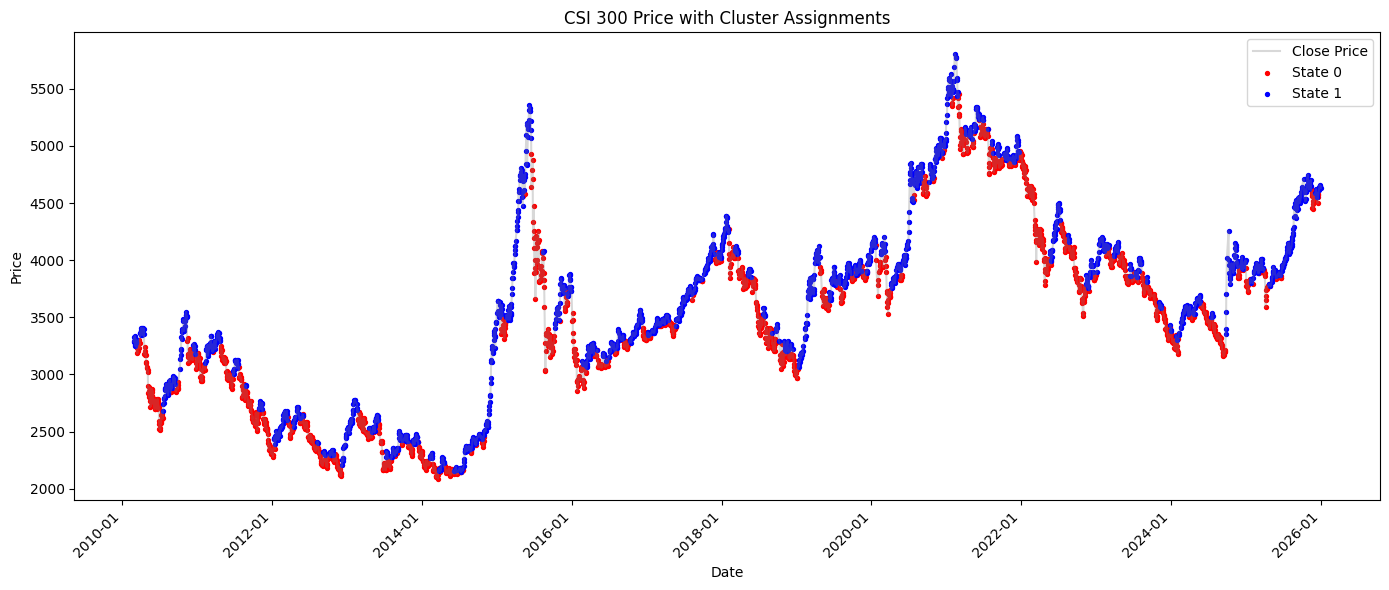

In [3]:
n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
full_df['Cluster'] = kmeans.fit_predict(X_scaled)

print("Cluster counts:")
print(full_df['Cluster'].value_counts())

plt.figure(figsize=(14, 6))
plt.plot(full_df.index, full_df['Close'], color='gray', alpha=0.3, label='Close Price')
colors = ['red', 'blue']
for i in range(n_clusters):
    mask = full_df['Cluster'] == i
    plt.scatter(full_df.index[mask], full_df['Close'][mask],
                color=colors[i], s=8, label=f'State {i}')
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.title('CSI 300 Price with Cluster Assignments')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

K=2: Silhouette=0.309, CH=2134.8, DB=1.239
K=3: Silhouette=0.228, CH=1552.1, DB=1.451
K=4: Silhouette=0.192, CH=1319.8, DB=1.573
K=5: Silhouette=0.196, CH=1187.1, DB=1.533
K=6: Silhouette=0.197, CH=1073.6, DB=1.499
K=7: Silhouette=0.201, CH=987.7, DB=1.439
K=8: Silhouette=0.174, CH=924.1, DB=1.498


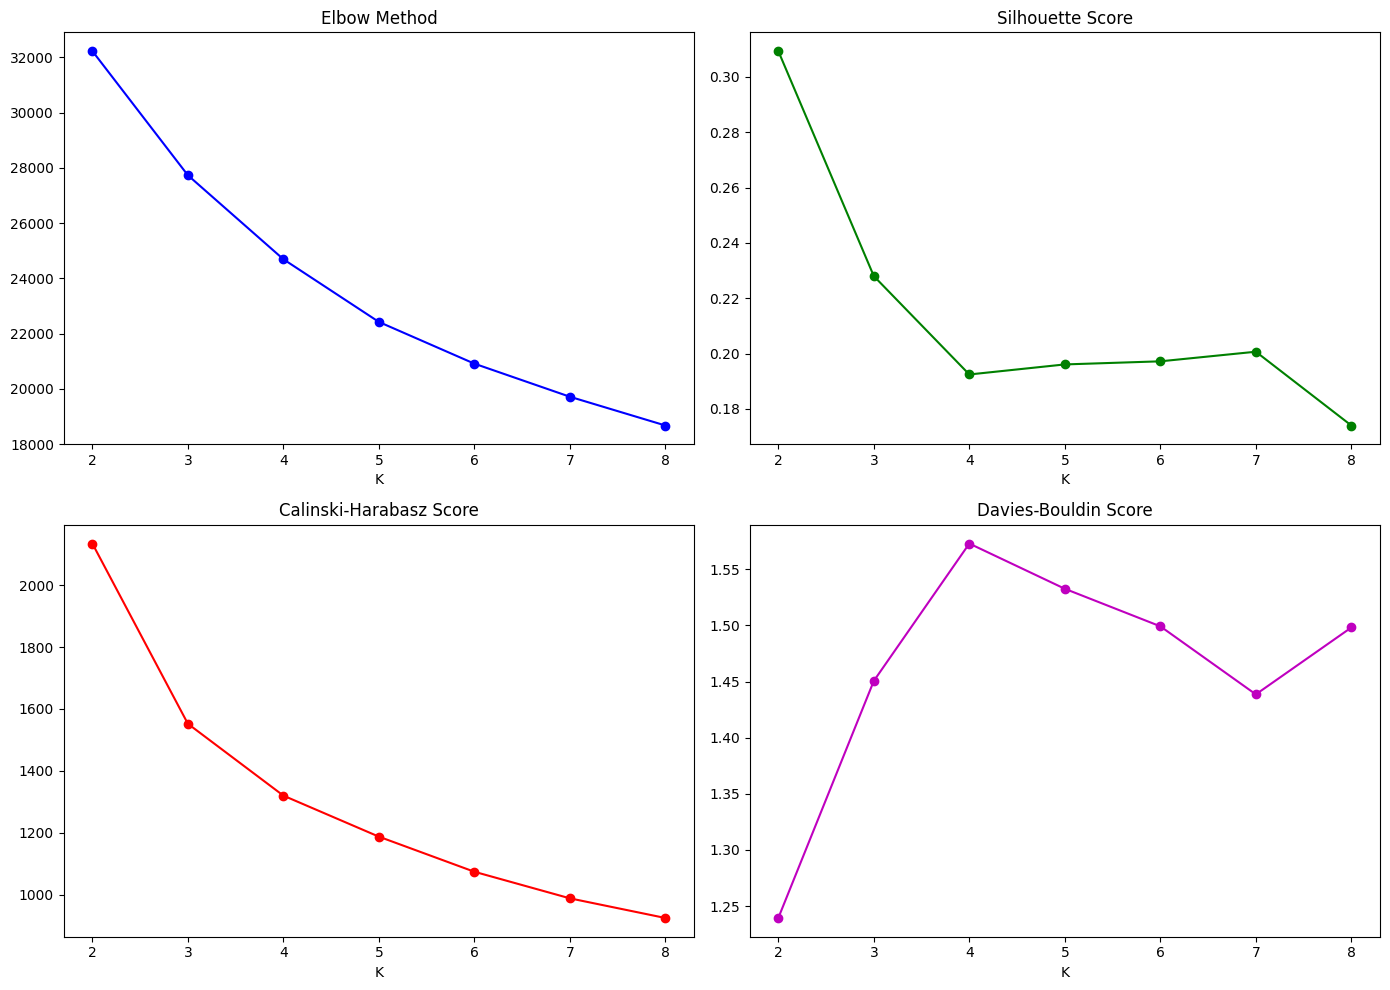

In [4]:
K_range = range(2, 9)
inertias, sils, chs, dbs = [], [], [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, labels))
    chs.append(calinski_harabasz_score(X_scaled, labels))
    dbs.append(davies_bouldin_score(X_scaled, labels))
    print(f"K={k}: Silhouette={sils[-1]:.3f}, CH={chs[-1]:.1f}, DB={dbs[-1]:.3f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0,0].plot(K_range, inertias, 'bo-')
axes[0,0].set_title('Elbow Method')
axes[0,1].plot(K_range, sils, 'go-')
axes[0,1].set_title('Silhouette Score')
axes[1,0].plot(K_range, chs, 'ro-')
axes[1,0].set_title('Calinski-Harabasz Score')
axes[1,1].plot(K_range, dbs, 'mo-')
axes[1,1].set_title('Davies-Bouldin Score')
for ax in axes.flat:
    ax.set_xlabel('K')
plt.tight_layout()
plt.show()

In [5]:
labels = full_df['Cluster'].values
dates = full_df.index
state_changes = np.diff(labels)
change_points = np.where(state_changes != 0)[0]

state_durations = {i: [] for i in range(n_clusters)}
current_state = labels[0]
current_start = 0
for i, state in enumerate(labels):
    if state != current_state:
        duration = i - current_start
        state_durations[current_state].append(duration)
        current_state = state
        current_start = i
state_durations[current_state].append(len(labels) - current_start)

print("State duration statistics (days):")
for st, dur in state_durations.items():
    if dur:
        print(f"  State {st}: avg={np.mean(dur):.0f}, min={np.min(dur)}, max={np.max(dur)}, switches={len(dur)}")
avg_dur = np.mean([d for dur in state_durations.values() for d in dur])
print(f"\nTotal switches: {len(change_points)}")
print(f"Average state duration: {avg_dur:.1f} days")

State duration statistics (days):
  State 0: avg=12, min=1, max=94, switches=159
  State 1: avg=12, min=1, max=97, switches=160

Total switches: 318
Average state duration: 12.1 days


In [6]:
full_df['Fwd5Ret'] = full_df['Close'].shift(-5) / full_df['Close'] - 1
full_df['Fwd5Dir'] = (full_df['Fwd5Ret'] > 0).astype(int)
full_df['Past5Ret'] = full_df['Close'] / full_df['Close'].shift(5) - 1
full_df['Past5Dir'] = (full_df['Past5Ret'] > 0).astype(int)

valid_f = full_df.dropna(subset=['Fwd5Ret'])
cm_fwd = confusion_matrix(valid_f['Fwd5Dir'], valid_f['Cluster'])
print("Confusion Matrix (Fwd5Dir vs Cluster):")
print(cm_fwd)
print(f"Agreement: {(valid_f['Cluster'] == valid_f['Fwd5Dir']).mean():.2%}")

valid_p = full_df.dropna(subset=['Past5Ret'])
cm_past = confusion_matrix(valid_p['Past5Dir'], valid_p['Cluster'])
print("\nConfusion Matrix (Past5Dir vs Cluster):")
print(cm_past)
print(f"Agreement: {(valid_p['Cluster'] == valid_p['Past5Dir']).mean():.2%}")

ari_f = adjusted_rand_score(valid_f['Fwd5Dir'], valid_f['Cluster'])
ari_p = adjusted_rand_score(valid_p['Past5Dir'], valid_p['Cluster'])
nmi_f = normalized_mutual_info_score(valid_f['Fwd5Dir'], valid_f['Cluster'])
nmi_p = normalized_mutual_info_score(valid_p['Past5Dir'], valid_p['Cluster'])
print(f"\nARI (Fwd): {ari_f:.4f}, ARI (Past): {ari_p:.4f}")
print(f"NMI (Fwd): {nmi_f:.4f}, NMI (Past): {nmi_p:.4f}")

Confusion Matrix (Fwd5Dir vs Cluster):
[[ 916  926]
 [1004 1002]]
Agreement: 49.84%

Confusion Matrix (Past5Dir vs Cluster):
[[1346  496]
 [ 574 1432]]
Agreement: 72.19%

ARI (Fwd): -0.0002, ARI (Past): 0.1968
NMI (Fwd): 0.0000, NMI (Past): 0.1475


In [7]:
def calc_momentum(series, n, **kwargs):
    return series / series.shift(n) - 1
def calc_price_bias(series, n, **kwargs):
    ma = series.rolling(n).mean()
    return (series - ma) / ma
def calc_vol_mean(series, n, **kwargs):
    return series.rolling(n).mean()
def calc_vol_bias(series, n, **kwargs):
    ma = series.rolling(n).mean()
    return (series / ma) - 1
def calc_new_low_ratio(series_low, n, **kwargs):
    is_low = series_low == series_low.rolling(n*2).min()
    return is_low.rolling(n).mean()
def calc_ma_alignment_ratio(series_close, n, **kwargs):
    ma5 = series_close.rolling(5).mean()
    ma20 = series_close.rolling(20).mean()
    ma60 = series_close.rolling(60).mean()
    bullish = (ma5 > ma20) & (ma20 > ma60)
    return bullish.rolling(n).mean()
def calc_adx(high, low, close, n, **kwargs):
    return talib.ADX(high.values, low.values, close.values, timeperiod=n)
def calc_volume_volatility(series_vol, n, **kwargs):
    chg = series_vol.pct_change()
    return chg.rolling(n).std()

class FactorSignalGenerator:
    def __init__(self, data):
        self.data = data.copy()
        self.signals = pd.DataFrame(index=data.index)
    def add_factor(self, name, func, fields, params, strategy, reverse=False):
        inputs = [self.data[f].squeeze() for f in fields]
        val = pd.Series(func(*inputs, **params), index=self.data.index)
        if strategy == 'boll':
            signal = self._boll(val, params.get('window',20))
        elif strategy == 'sma':
            signal = self._sma(val, params.get('window',20))
        elif strategy == 'mom':
            signal = self._mom(val, params.get('window',20))
        else:
            raise ValueError(strategy)
        if reverse:
            signal = -signal
        self.signals[name] = signal
    def _boll(self, ser, window, k=2.0):
        mb = ser.rolling(window).mean()
        std = ser.rolling(window).std()
        up, dn = mb + k*std, mb - k*std
        sig = pd.Series(np.nan, index=ser.index)
        sig[ser > up] = 1
        sig[ser < dn] = -1
        return sig.ffill().fillna(0)
    def _sma(self, ser, window):
        ma = ser.rolling(window).mean()
        sig = pd.Series(0, index=ser.index)
        sig[ser > ma] = 1
        sig[ser < ma] = -1
        sig[ma.isna()] = 0
        return sig
    def _mom(self, ser, window):
        past = ser.shift(window)
        sig = pd.Series(0, index=ser.index)
        sig[ser > past] = 1
        sig[ser < past] = -1
        sig[past.isna()] = 0
        return sig

In [8]:
class StrategyBackTester:
    def __init__(self, data):
        self.data = data
    def calc_return(self, signals, initial_cash=1e6, lot_size=100,
                    slippage=0.002, limit=0.098):
        buy_fee, sell_fee = 0.0003, 0.0013
        common = signals.index.intersection(self.data.index)
        signals = signals.loc[common]
        if len(signals) < 2:
            return pd.Series(dtype=float)
        o = self.data.loc[common, 'Open'].values
        c = self.data.loc[common, 'Close'].values
        sig = signals.values
        dates = signals.index
        cash, shares = initial_cash, 0.0
        last_buy = None
        daily_val = [initial_cash]
        for i in range(1, len(sig)):
            target = sig[i-1]
            open_p, prev_close = o[i], c[i-1]
            if pd.isna(open_p) or open_p<=0 or pd.isna(prev_close):
                daily_val.append(daily_val[-1])
                continue
            buy_p = open_p * (1+slippage)
            sell_p = open_p * (1-slippage)
            if target==1 and shares==0:
                if open_p < prev_close*(1+limit):
                    max_shares = cash / (buy_p*(1+buy_fee))
                    actual = int(max_shares//lot_size)*lot_size
                    if actual>0:
                        shares = actual
                        cash -= actual*buy_p*(1+buy_fee)
                        last_buy = dates[i]
            elif target<=0 and shares>0:
                if open_p > prev_close*(1-limit) and last_buy is not None and dates[i]>last_buy:
                    cash += shares*sell_p*(1-sell_fee)
                    shares = 0.0
            close_p = c[i]
            if pd.isna(close_p) or close_p<=0:
                close_p = prev_close
            daily_val.append(cash + shares*close_p)
        if shares>0:
            cash += shares*c[-1]*(1-sell_fee)
            daily_val[-1] = cash
        return pd.Series(daily_val, index=dates).pct_change().fillna(0)

def optimize_single_threshold(signals_df, next_ret, state_series,
                               th_range=np.arange(0.05,0.5,0.05)):
    states = sorted(state_series.unique())
    best = {}
    eq_signal = signals_df.mean(axis=1)
    for st in states:
        mask = state_series == st
        sig = eq_signal.loc[mask]
        ret = next_ret.loc[mask]
        common = sig.index.intersection(ret.index)
        sig, ret = sig.loc[common], ret.loc[common]
        if len(sig) < 50:
            best[st] = 0.25
            continue
        best_sharpe = -np.inf
        best_th = 0.25
        for th in th_range:
            s = pd.Series(0, index=sig.index)
            s[sig > th] = 1
            s[sig < -th] = -1
            sr = s * ret
            if len(sr)>10:
                sh = sr.mean() / (sr.std()+1e-8) * np.sqrt(252)
                if sh > best_sharpe:
                    best_sharpe = sh
                    best_th = th
        best[st] = best_th
    return best

In [9]:
TRAIN_YEARS = 1
TEST_YEARS = 1
N_STATES = 2
FIXED_TH = 0.125

raw_bt = raw.copy()   # reuse full data
tech_bt = full_df.copy()
# Generate factor signals
sig_gen = FactorSignalGenerator(raw_bt)
sig_gen.add_factor('Mom_60_120', calc_momentum, ['Close'], {'n':60,'window':120}, 'boll')
sig_gen.add_factor('Bias_10_20', calc_price_bias, ['Close'], {'n':10,'window':20}, 'boll')
sig_gen.add_factor('VolMean_10_20', calc_vol_mean, ['Volume'], {'n':10,'window':20}, 'sma')
sig_gen.add_factor('VolBias_60_150', calc_vol_bias, ['Volume'], {'n':60,'window':150}, 'boll')
sig_gen.add_factor('NewLow_20_50', calc_new_low_ratio, ['Low'], {'n':20,'window':50}, 'boll')
sig_gen.add_factor('MAAlign_10_30_rev', calc_ma_alignment_ratio, ['Close'], {'n':10,'window':30}, 'boll', reverse=True)
sig_gen.add_factor('ADX_60_150', calc_adx, ['High','Low','Close'], {'n':60,'window':150}, 'mom')
sig_gen.add_factor('VolVol_20_50', calc_volume_volatility, ['Volume'], {'n':20,'window':50}, 'boll')
sig_df = sig_gen.signals.dropna()

daily_ret = raw_bt['Close'].pct_change().fillna(0)
next_ret = daily_ret.shift(-1).fillna(0)

common_idx = sig_df.index.intersection(next_ret.index).intersection(tech_bt.index)
sig_df = sig_df.loc[common_idx]
next_ret = next_ret.loc[common_idx]
tech_bt = tech_bt.loc[common_idx]
raw_bt = raw_bt.loc[common_idx]

start_date = common_idx.min()
end_date = common_idx.max()

In [10]:
train_offset = pd.DateOffset(years=TRAIN_YEARS)
test_offset = pd.DateOffset(years=TEST_YEARS)
current = start_date

all_state, all_global, all_fixed = [], [], []
all_states = []

bt = StrategyBackTester(raw_bt)

window_count = 0
while current + train_offset + test_offset <= end_date:
    train_start, train_end = current, current + train_offset
    test_start, test_end = train_end, train_end + test_offset
    w_idx = common_idx[(common_idx >= train_start) & (common_idx < test_end)]
    tr_idx = w_idx[w_idx < train_end]
    te_idx = w_idx[w_idx >= test_start]
    if len(tr_idx) < 50 or len(te_idx) < 1:
        current += test_offset
        continue
    window_count += 1
    print(f"  Window {window_count}: {test_start.date()} to {test_end.date()}")

    X_tr = tech_bt.loc[tr_idx, feature_cols].values
    scaler_bt = StandardScaler().fit(X_tr)
    km = KMeans(n_clusters=N_STATES, random_state=42, n_init=10).fit(scaler_bt.transform(X_tr))
    X_w = tech_bt.loc[w_idx, feature_cols].values
    ws = pd.Series(km.predict(scaler_bt.transform(X_w)), index=w_idx)

    state_th = optimize_single_threshold(sig_df.loc[tr_idx], next_ret.loc[tr_idx], ws.loc[tr_idx])
    global_th = optimize_single_threshold(sig_df.loc[tr_idx], next_ret.loc[tr_idx], pd.Series(0, index=tr_idx))
    gth = global_th[0]

    eq = sig_df.mean(axis=1)
    ss, gs, fs = [], [], []
    for dt in te_idx:
        s = ws.loc[dt]
        v = eq.loc[dt]
        th = state_th[s]
        ss.append(1 if v>th else -1 if v<-th else 0)
        gs.append(1 if v>gth else -1 if v<-gth else 0)
        fs.append(1 if v>FIXED_TH else -1 if v<-FIXED_TH else 0)

    all_state.append(pd.Series(ss, index=te_idx))
    all_global.append(pd.Series(gs, index=te_idx))
    all_fixed.append(pd.Series(fs, index=te_idx))
    all_states.append(ws.loc[te_idx])
    current += test_offset

print(f"\nTotal windows completed: {window_count}")
state_sig = pd.concat(all_state).sort_index()
global_sig = pd.concat(all_global).sort_index()
fixed_sig = pd.concat(all_fixed).sort_index()
state_labels = pd.concat(all_states).sort_index()

state_ret = bt.calc_return(state_sig)
global_ret = bt.calc_return(global_sig)
fixed_ret = bt.calc_return(fixed_sig)
bench_ret = (raw_bt['pctChg'] / 100).fillna(0).loc[state_sig.index]

  Window 1: 2011-02-25 to 2012-02-25
  Window 2: 2012-02-25 to 2013-02-25
  Window 3: 2013-02-25 to 2014-02-25
  Window 4: 2014-02-25 to 2015-02-25
  Window 5: 2015-02-25 to 2016-02-25
  Window 6: 2016-02-25 to 2017-02-25
  Window 7: 2017-02-25 to 2018-02-25
  Window 8: 2018-02-25 to 2019-02-25
  Window 9: 2019-02-25 to 2020-02-25
  Window 10: 2020-02-25 to 2021-02-25
  Window 11: 2021-02-25 to 2022-02-25
  Window 12: 2022-02-25 to 2023-02-25
  Window 13: 2023-02-25 to 2024-02-25
  Window 14: 2024-02-25 to 2025-02-25

Total windows completed: 14


WALK-FORWARD OUT-OF-SAMPLE RESULTS

State-Optimized Threshold:
  Cumulative Return: 293.2059%
  Annual Return: 10.6807%
  Sharpe Ratio: 0.8087
  Max Drawdown: -23.7205%
  Win Rate: 21.53%

Global Dynamic Threshold:
  Cumulative Return: 207.4706%
  Annual Return: 8.6813%
  Sharpe Ratio: 0.7242
  Max Drawdown: -27.4847%
  Win Rate: 20.74%

Fixed Threshold ±0.125:
  Cumulative Return: 152.8926%
  Annual Return: 7.1185%
  Sharpe Ratio: 0.5341
  Max Drawdown: -31.9200%
  Win Rate: 27.59%

CSI 300 Benchmark:
  Cumulative Return: 24.4078%
  Annual Return: 1.6319%
  Sharpe Ratio: 0.1835
  Max Drawdown: -46.6961%
  Win Rate: 50.56%

Threshold Usage Stats:
  State strategy trade days: 1866 (54.9%)
  Global dynamic trade days: 1760 (51.8%)
  Fixed threshold trade days: 2528 (74.4%)


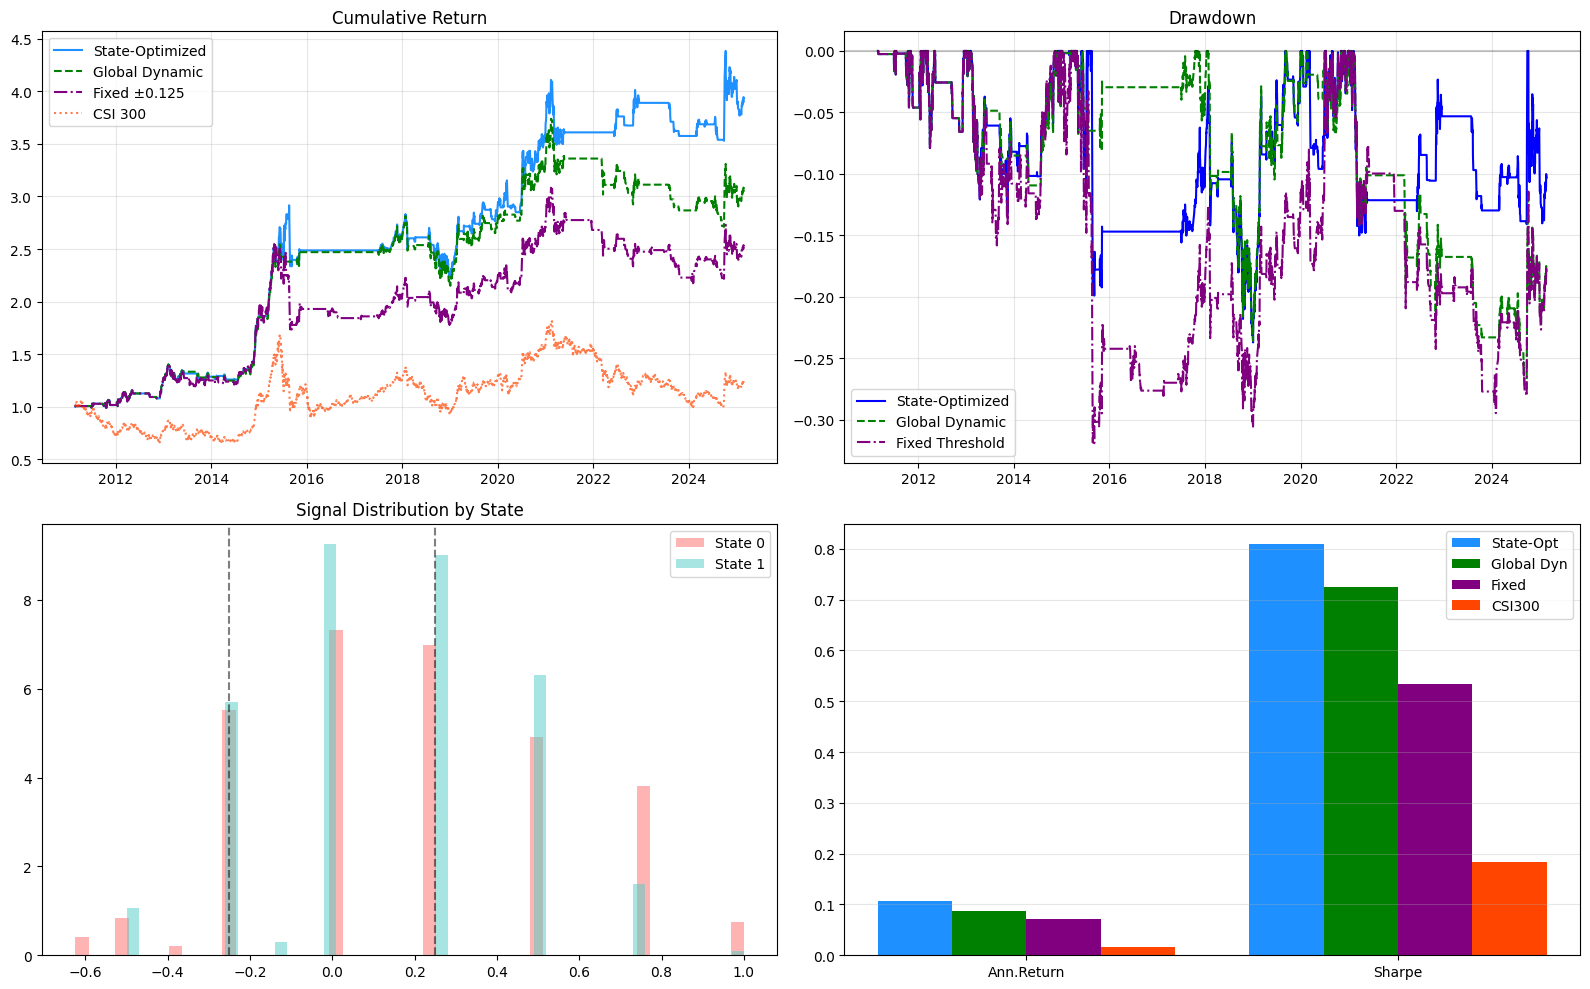

In [11]:
def evaluate(ret, name=""):
    cum = (1+ret).cumprod()
    total = cum.iloc[-1]-1
    ann = (1+total)**(252/len(ret))-1 if len(ret)>0 else 0
    sharpe = ret.mean()/ret.std()*np.sqrt(252) if ret.std()!=0 else 0
    mdd = (cum/cum.cummax()-1).min()
    wr = (ret>0).mean()
    print(f"\n{name}:")
    print(f"  Cumulative Return: {total:.4%}")
    print(f"  Annual Return: {ann:.4%}")
    print(f"  Sharpe Ratio: {sharpe:.4f}")
    print(f"  Max Drawdown: {mdd:.4%}")
    print(f"  Win Rate: {wr:.2%}")
    return {'Cum':total, 'Ann':ann, 'Sharpe':sharpe, 'MDD':mdd, 'Win':wr}

print("="*60)
print("WALK-FORWARD OUT-OF-SAMPLE RESULTS")
print("="*60)
state_perf = evaluate(state_ret, "State-Optimized Threshold")
global_perf = evaluate(global_ret, "Global Dynamic Threshold")
fixed_perf = evaluate(fixed_ret, f"Fixed Threshold ±{FIXED_TH}")
bench_perf = evaluate(bench_ret, "CSI 300 Benchmark")

print("\nThreshold Usage Stats:")
print(f"  State strategy trade days: {(state_sig!=0).sum()} ({(state_sig!=0).mean():.1%})")
print(f"  Global dynamic trade days: {(global_sig!=0).sum()} ({(global_sig!=0).mean():.1%})")
print(f"  Fixed threshold trade days: {(fixed_sig!=0).sum()} ({(fixed_sig!=0).mean():.1%})")

fig, axes = plt.subplots(2,2, figsize=(16,10))
axes[0,0].plot((1+state_ret).cumprod(), label='State-Optimized', color='#1E90FF')
axes[0,0].plot((1+global_ret).cumprod(), label='Global Dynamic', color='green', ls='--')
axes[0,0].plot((1+fixed_ret).cumprod(), label=f'Fixed ±{FIXED_TH}', color='purple', ls='-.')
axes[0,0].plot((1+bench_ret).cumprod(), label='CSI 300', color='#FF4500', ls=':', alpha=0.7)
axes[0,0].set_title('Cumulative Return')
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

sd = (1+state_ret).cumprod() / (1+state_ret).cumprod().cummax() -1
gd = (1+global_ret).cumprod() / (1+global_ret).cumprod().cummax() -1
fd = (1+fixed_ret).cumprod() / (1+fixed_ret).cumprod().cummax() -1
axes[0,1].plot(sd.index, sd, color='blue', label='State-Optimized')
axes[0,1].plot(gd.index, gd, color='green', ls='--', label='Global Dynamic')
axes[0,1].plot(fd.index, fd, color='purple', ls='-.', label='Fixed Threshold')
axes[0,1].axhline(0, color='k', alpha=0.2)
axes[0,1].set_title('Drawdown')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

eq_all = sig_df.mean(axis=1).loc[state_sig.index]
for st in [0,1]:
    axes[1,0].hist(eq_all[state_labels==st], bins=50, alpha=0.5, density=True,
                   label=f'State {st}', color=['#FF6B6B','#4ECDC4'][st])
axes[1,0].axvline(0.25, color='k', ls='--', alpha=0.5)
axes[1,0].axvline(-0.25, color='k', ls='--', alpha=0.5)
axes[1,0].set_title('Signal Distribution by State')
axes[1,0].legend()

x = np.arange(2)
width = 0.2
axes[1,1].bar(x-1.5*width, [state_perf['Ann'], state_perf['Sharpe']], width, color='#1E90FF', label='State-Opt')
axes[1,1].bar(x-0.5*width, [global_perf['Ann'], global_perf['Sharpe']], width, color='green', label='Global Dyn')
axes[1,1].bar(x+0.5*width, [fixed_perf['Ann'], fixed_perf['Sharpe']], width, color='purple', label='Fixed')
axes[1,1].bar(x+1.5*width, [bench_perf['Ann'], bench_perf['Sharpe']], width, color='#FF4500', label='CSI300')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(['Ann.Return','Sharpe'])
axes[1,1].legend()
axes[1,1].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
print("\n" + "="*60)
print("Annual Returns")
print("="*60)
sc = (1+state_ret).cumprod()
gc = (1+global_ret).cumprod()
fc = (1+fixed_ret).cumprod()
bc = (1+bench_ret).cumprod()

ys = sc.resample('Y').last().pct_change()
yg = gc.resample('Y').last().pct_change()
yf = fc.resample('Y').last().pct_change()
yb = bc.resample('Y').last().pct_change()

df_yearly = pd.DataFrame({'State-Opt': ys, 'Global Dyn': yg, 'Fixed': yf, 'CSI300': yb}).dropna()
print(df_yearly.to_string(float_format=lambda x: f'{x:.2%}'))
print(f"\nAverage Annual Return:")
print(f"  State-Optimized: {ys.mean():.2%}")
print(f"  Global Dynamic: {yg.mean():.2%}")
print(f"  Fixed Threshold: {yf.mean():.2%}")
print(f"  CSI 300:        {yb.mean():.2%}")


Annual Returns
            State-Opt  Global Dyn   Fixed  CSI300
trade_date                                       
2012-12-31     25.40%      25.40%  25.40%   7.55%
2013-12-31      0.90%       0.56%  -1.94%  -7.65%
2014-12-31     44.51%      44.19%  52.81%  51.66%
2015-12-31     33.77%      33.63%   1.02%   5.58%
2016-12-31      0.00%       0.00%  -4.50% -11.28%
2017-12-31      5.18%       5.21%  11.06%  21.77%
2018-12-31    -13.75%     -16.03% -12.58% -25.31%
2019-12-31     28.87%      27.19%  24.46%  36.07%
2020-12-31     26.95%      21.79%  25.02%  27.21%
2021-12-31     -2.21%      -0.61%  -3.70%  -5.20%
2022-12-31      7.77%      -7.39%  -7.71% -21.63%
2023-12-31     -8.09%      -7.87%  -9.96% -11.38%
2024-12-31     13.10%       6.51%  12.69%  14.68%
2025-12-31     -2.75%       0.68%   0.71%   0.88%

Average Annual Return:
  State-Optimized: 11.40%
  Global Dynamic: 9.52%
  Fixed Threshold: 8.05%
  CSI 300:        5.93%
